In [1]:
2+2

4

In [2]:
import os
os.environ["HDF5_USE_FILE_LOCKING"] = "FALSE"
import xarray as xr
path = "/Volumes/opto_loc/Data/ACR_39/swi-bl-NNXo.nc"
da = xr.open_dataarray(path)

/tmp/ipykernel_3227566/1504366668.py:5: FutureWarning: In a future version, xarray will not decode timedelta values based on the presence of a timedelta-like units attribute by default. Instead it will rely on the presence of a timedelta64 dtype attribute, which is now xarray's default way of encoding timedelta64 values. To continue decoding timedeltas based on the presence of a timedelta-like units attribute, users will need to explicitly opt-in by passing True or CFTimedeltaCoder(decode_via_units=True) to decode_timedelta. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  da = xr.open_dataarray(path)


In [4]:
#-------------------------- Standard Imports --------------------------#
%reload_ext autoreload
%autoreload 2
import kdephys as kde
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import acr
import xarray as xr
from scipy import stats
# ---------------------------- EXTRAS --------------------------------#
from kdephys.plot.main import _title, bp_plot
import kdephys.utils.spectral as sp
bands = sp.bands
from scipy.stats import normaltest
import warnings
warnings.filterwarnings('ignore')
import matplotlib as mpl
from acr.utils import *
#pu = acr.utils.import_publication_functions('/Users/driessen2@ad.wisc.edu/kdriessen/gh_master/PUBLICATION__ACR/pub_utils.py', 'pu')
dag = acr.utils.import_publication_functions('/Users/driessen2@ad.wisc.edu/kdriessen/gh_master/PUBLICATION__ACR/data_agg.py', 'dag')
import pingouin as pg
from scipy.stats import shapiro

plt.rcdefaults()

In [5]:
subject = 'ACR_57'
exp = 'mart'
recs = acr.info_pipeline.get_exp_recs(subject, exp)
# Load the Full Exp field potentials
lfp = acr.io.load_concat_raw_data(subject, recs)

In [70]:
# load the full hypnogram for the experiment
# hypno = acr.io.load_hypno_full_exp(subject, exp)

# For this notebook we will just use the SD hypno since we don't have the full hypnogram yet:
hypno = acr.io.load_hypno(subject, exp, corrections=True)

In [8]:
# load the MUA data
mua = acr.mua.load_concat_peaks_df(subject, exp)

In [10]:
rt = acr.info_pipeline.subject_info_section(subject, 'rec_times')
exp_start = pd.Timestamp(rt['mart']['start'])

In [11]:
stim_start, stim_end, pon, poff, ton, toff = acr.stim.get_all_stim_info(subject, exp)

In [ ]:
from kdephys.hypno.ecephys_hypnogram import DatetimeHypnogram

In [56]:
true_sd_start = hypno['start_time'][0]
sd_dict = {}
sd_dict['early_sd'] = hypno.keep_states(['Wake']).keep_first('3600s')
sd_dict['late_sd'] = hypno.trim_select(true_sd_start, stim_start).keep_states(['Wake']).keep_last('3600s')
#sd_dict['stim'] = pl.DataFrame({'start_datetime': [stim_start], 'end_datetime': [stim_end], 'state': ['Wake'], 'duration': [pd.Timedelta(stim_end - stim_start).total_seconds()]})

In [84]:
stim_hypnos = []
for s, e in zip(pon, poff):
    stim_hypno = hypno.trim_select(s, e).keep_states(['Wake'])
    stim_hypnos.append(stim_hypno._df)
full_stim_hypno = DatetimeHypnogram(pd.concat(stim_hypnos))
sd_dict['stim'] = full_stim_hypno

In [85]:
interval_hypnos = []
for i in range(len(pon)-1):
    s = poff[i]
    e = pon[i+1]
    interval_hypno = hypno.trim_select(s, e).keep_states(['Wake'])
    interval_hypnos.append(interval_hypno._df)
full_interval_hypno = DatetimeHypnogram(pd.concat(interval_hypnos))
sd_dict['inter-stim'] = full_interval_hypno

In [55]:
# Compute OFF Periods: 50ms min duration
# only need to run this once to save, if you rerun this will recompute and overwrite
acr.onoffmua.gen_and_save_base_oodfs(subject, exp, mua=mua, off_min_dur=0.05, synth_dur=2.0, segs=False)

KeyboardInterrupt: 

# Experimental Design

The design of the experiment was as follows:
- Mice had inhibitory ACR opsin expressed in SOM+ neurons. 
- SD via novel objects from 9am to 2:15 pm
- From 1:30 - 2:15 (final 45 min of SD), laser was turned on for inhibition of SOM+ neurons. Laser was on for 20s, off for 40s. This process was repeated for the entire 45 min, resulting in 45 total stimulations.
- All of these analyses focus on comparing the stimulus period to the inter-stim period and preceding 4.5 hours of SD. 

# Whole-Probe OFF Period Detection

Here we use the canonical OFF period definition, where there must be at least 50ms of TOTAL MUA silence (i.e. no spikes on any channel) to be considered an OFF period:

In [93]:
wp = acr.onoffmua.load_base_oodfs(subject, exp, version='whole-probe')
wp_offs = wp.offs()
wp_freq = acr.oo_utils.calc_off_freq(wp_offs, window='5s')

In [94]:
wp_offs = acr.hypnogram_utils.label_df_with_hypno_conditions(wp_offs, sd_dict, col='end_datetime', label_col='epoch')
wp_offs = acr.hypnogram_utils.label_df_with_states(wp_offs, hypno, col='end_datetime')

Text(0.5, 1.0, 'OFF Frequency over Time | Top: 48 hours, Bottom: Zoomed to 5-hour SD and Stim Periods')

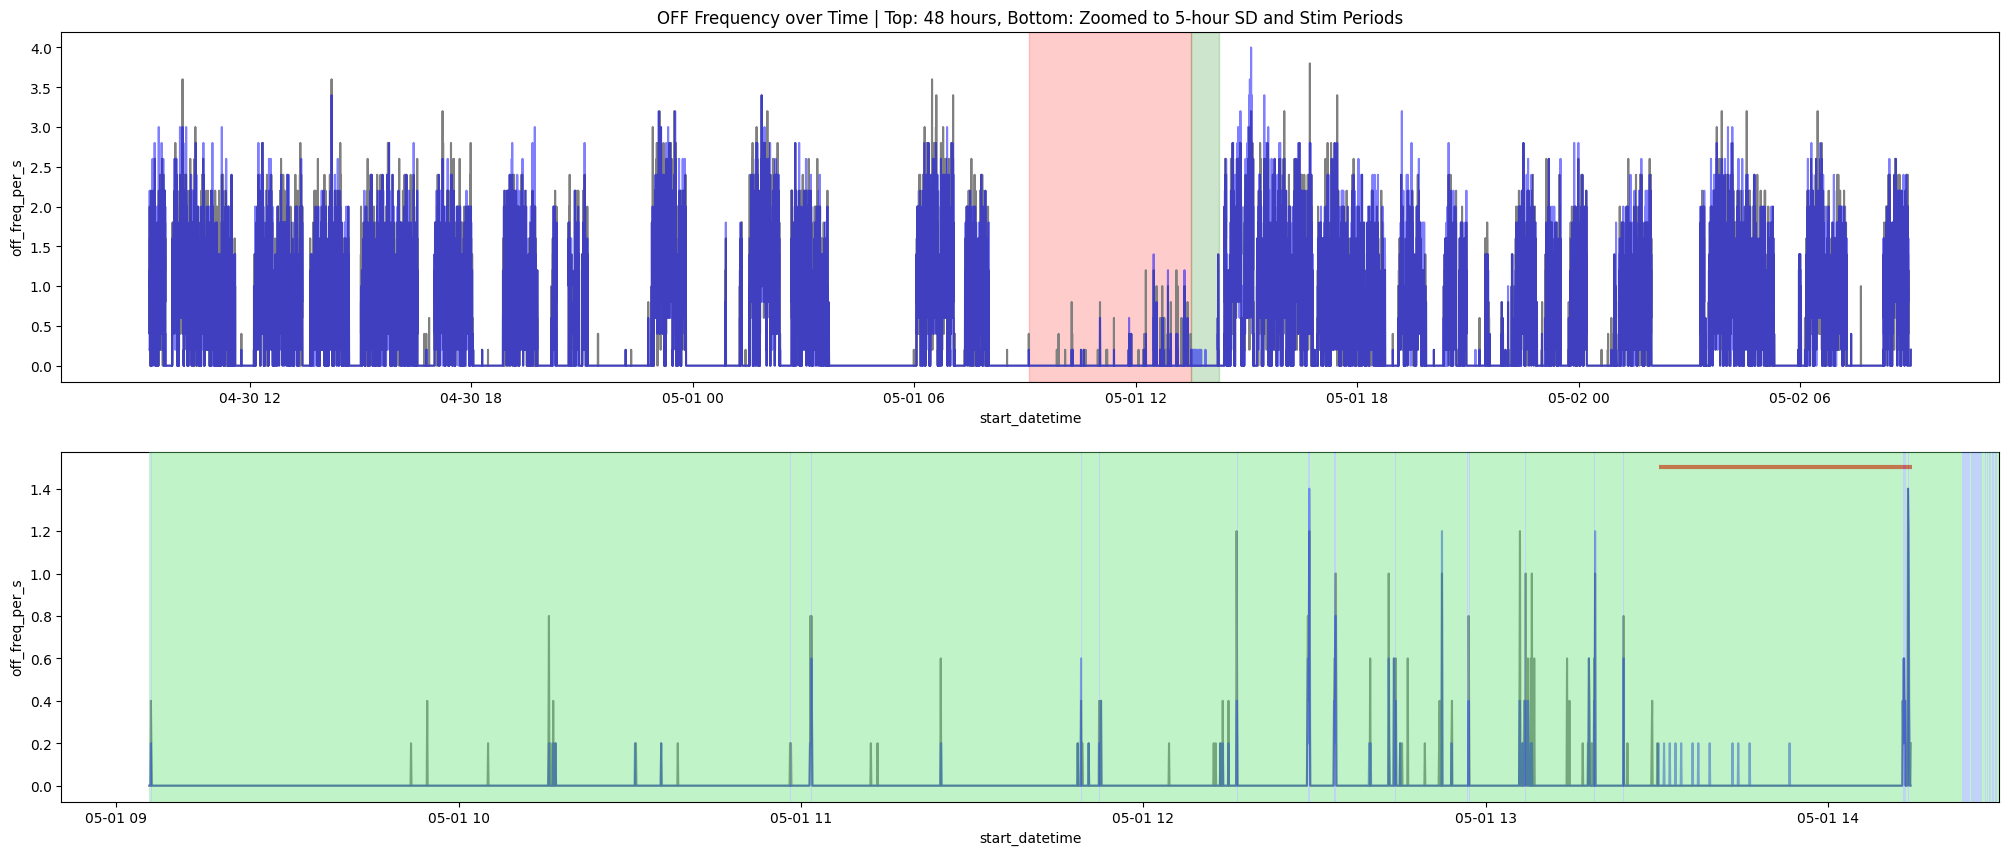

In [64]:
f, ax = plt.subplots(2, 1, figsize=(25, 10))
sns.lineplot(x='start_datetime', y='off_freq_per_s', color='gray', data=wp_freq.prb('NNXr'), alpha=1, ax=ax[0])
sns.lineplot(x='start_datetime', y='off_freq_per_s', color='blue', data=wp_freq.prb('NNXo'), alpha=0.5, ax=ax[0])
ax[0].axvspan(exp_start, stim_start, color='red', alpha=0.2)
ax[0].axvspan(stim_start, stim_end, color='green', alpha=0.2)
sns.lineplot(x='start_datetime', y='off_freq_per_s', color='gray', data=wp_freq.prb('NNXr').oots(exp_start, stim_end), alpha=1, ax=ax[1])
sns.lineplot(x='start_datetime', y='off_freq_per_s', color='blue', data=wp_freq.prb('NNXo').oots(exp_start, stim_end), alpha=0.5, ax=ax[1])
#for i in range(len(pon)):
#    ax[1].axvspan(pon[i], poff[i], color='green', alpha=0.2)
#ax[1].axvspan(exp_start, stim_start, color='red', alpha=0.2)
#ax[1].axvspan(stim_start, stim_end, color='green', alpha=0.2)
ax[1] = kde.plot.main.shade_hypno_for_me(hypno, ax[1], alpha=0.4)
ax[1].hlines(1.5, stim_start, stim_end, color='red', alpha=0.8, linewidth=3)
ax[0].set_title('OFF Frequency over Time | Top: 48 hours, Bottom: Zoomed to 5-hour SD and Stim Periods')

In [92]:
sd_dict['early_sd']['duration'].sum().total_seconds()

3600.0

In [ ]:
early_sd_period = (exp_start, exp_start + pd.Timedelta(minutes=60))
late_sd_period = (stim_start-pd.Timedelta(minutes=60), stim_start)
stim_periods = [(laser_on, laser_off) for laser_on, laser_off in zip(pon, poff)]
inter_stim_periods = [(poff[i], pon[i+1]) for i in range(len(pon)-1)]

early_sd_dur = sd_dict['early_sd']['duration'].sum().total_seconds()
late_sd_dur = sd_dict['late_sd']['duration'].sum().total_seconds()
stim_dur = sd_dict['stim']['duration'].sum().total_seconds()
inter_stim_dur = sd_dict['inter-stim']['duration'].sum().total_seconds()
durations = {
    'early_sd': early_sd_dur,
    'late_sd': late_sd_dur,
    'stim': stim_dur,
    'inter-stim': inter_stim_dur
}



# create an epoch column in wp_offs that labels each row as 'sd', 'stim', or 'inter-stim'
# based on which period each OFF period's start_datetime falls into
ref = pl.col('start_datetime')

def _in_any(periods):
    expr = pl.lit(False)
    for start, end in periods:
        expr = expr | ref.is_between(start, end)
    return expr

#wp_offs = wp_offs.with_columns(
#    pl.when(ref.is_between(*early_sd_period)).then(pl.lit('early_sd'))
#      .when(ref.is_between(*late_sd_period)).then(pl.lit('late_sd'))
#      .when(_in_any(stim_periods)).then(pl.lit('stim'))
#      .when(_in_any(inter_stim_periods)).then(pl.lit('inter-stim'))
#      .otherwise(None)
#      .alias('epoch')
#)

wp_offs = wp_offs.with_columns(
    pl.col('epoch').replace_strict(durations, default=None).alias('epoch_dur_s')
)
wp_offs = wp_offs.with_columns(
    pl.when(pl.col('epoch') == 'None')
      .then(pl.lit(None).cast(pl.Utf8))
      .otherwise(pl.col('epoch'))
      .alias('epoch')
)

In [102]:
counts = wp_offs.filter(pl.col('epoch').is_not_null()).group_by(['epoch', 'probe']).agg(
    pl.count().alias('num_off_periods'),
    pl.mean('duration').alias('mean_duration'))
counts = counts.with_columns(
    pl.col('epoch').replace_strict(durations, default=None).alias('epoch_dur_s')
)
counts = counts.with_columns(
    (pl.col('num_off_periods') / pl.col('epoch_dur_s')).alias('off_periods_per_s')
)
counts = dag.relativize_df(counts, ref_to_col='epoch', ref_to_val='early_sd', avg_method='mean', col_to_relativize='off_periods_per_s', on=['probe'])
counts = dag.relativize_df(counts, ref_to_col='epoch', ref_to_val='early_sd', avg_method='mean', col_to_relativize='mean_duration', on=['probe'])

Text(0.5, 1.0, 'Mean OFF Period Frequency by Epoch and Probe, Relative to early SD')

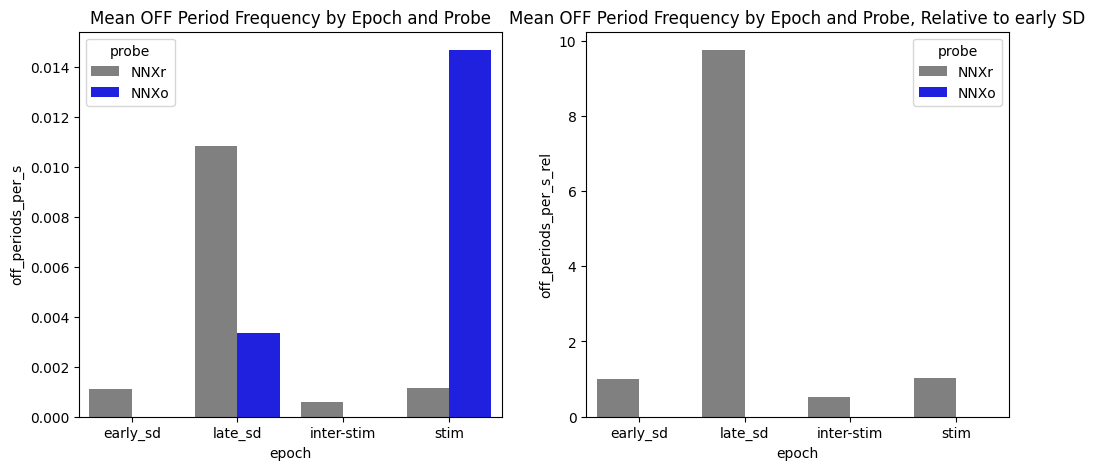

In [103]:
f, ax = plt.subplots(1, 2, figsize=(12, 5))

ax[0] = sns.barplot(data=counts.to_pandas(), x='epoch', y='off_periods_per_s', hue='probe', hue_order=['NNXr', 'NNXo'], order=['early_sd', 'late_sd', 'inter-stim', 'stim'], palette=['gray', 'blue'], ax=ax[0])
ax[0].set_title('Mean OFF Period Frequency by Epoch and Probe')

ax[1] = sns.barplot(data=counts.to_pandas(), x='epoch', y='off_periods_per_s_rel', hue='probe', hue_order=['NNXr', 'NNXo'], order=['early_sd', 'late_sd', 'inter-stim', 'stim'], palette=['gray', 'blue'], ax=ax[1])
ax[1].set_title('Mean OFF Period Frequency by Epoch and Probe, Relative to early SD')

Text(0.5, 1.0, 'Mean OFF Period Duration by Epoch and Probe, Relative to early SD')

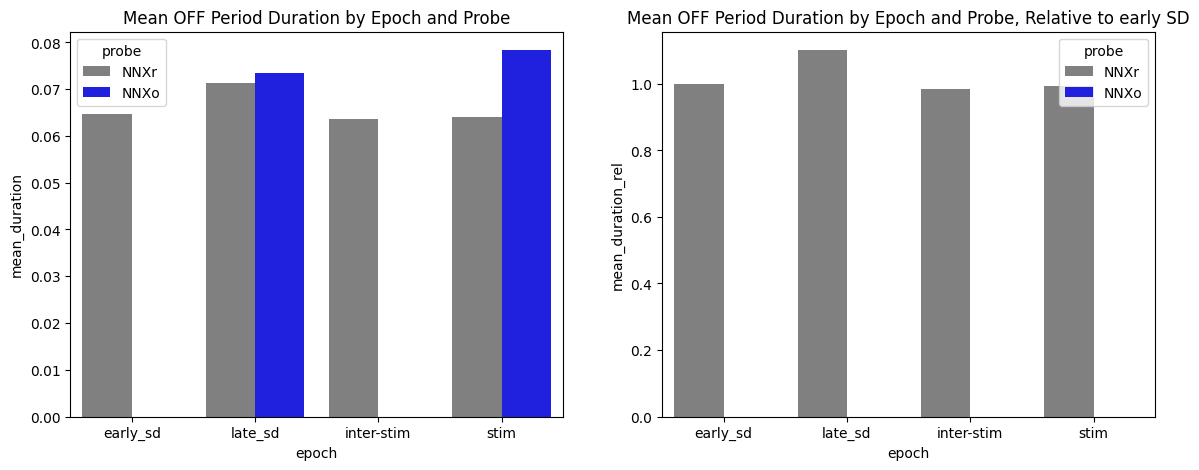

In [104]:
f, ax = plt.subplots(1, 2, figsize=(14, 5))

ax[0] = sns.barplot(data=counts.to_pandas(), x='epoch', y='mean_duration', hue='probe', hue_order=['NNXr', 'NNXo'], order=['early_sd', 'late_sd', 'inter-stim', 'stim'], palette=['gray', 'blue'], ax=ax[0])
ax[0].set_title('Mean OFF Period Duration by Epoch and Probe')
ax[1] = sns.barplot(data=counts.to_pandas(), x='epoch', y='mean_duration_rel', hue='probe', hue_order=['NNXr', 'NNXo'], order=['early_sd', 'late_sd', 'inter-stim', 'stim'], palette=['gray', 'blue'], ax=ax[1])
ax[1].set_title('Mean OFF Period Duration by Epoch and Probe, Relative to early SD')

# Hybrid OFF Period Detection

Here we first detect OFF periods at the single-channel level, and we then detect global OFF periods as those periods where some threshold number of single channels (12/16) are simultaneously in an OFF period. This is the exact definition used in the nature neuroscience paper. 

In [ ]:
sc = acr.onoffmua.load_base_oodfs(subject, exp, version='single-chan')
sc_offs = sc.offs()
sc_freq = acr.oo_utils.calc_off_freq(sc_offs, window='5s')

: 

: 

In [ ]:
wp_offs = acr.onoffmua.compute_hybrid_off_df(subject, exp)

In [106]:
wp_offs = acr.hypnogram_utils.label_df_with_hypno_conditions(wp_offs, sd_dict, col='end_datetime', label_col='epoch')
wp_offs = acr.hypnogram_utils.label_df_with_states(wp_offs, hypno, col='end_datetime')

In [107]:
wp_freq = acr.oo_utils.calc_off_freq(wp_offs, window='5s')

Text(0.5, 1.0, 'OFF Frequency over Time | Top: 48 hours, Bottom: Zoomed to 5-hour SD and Stim Periods')

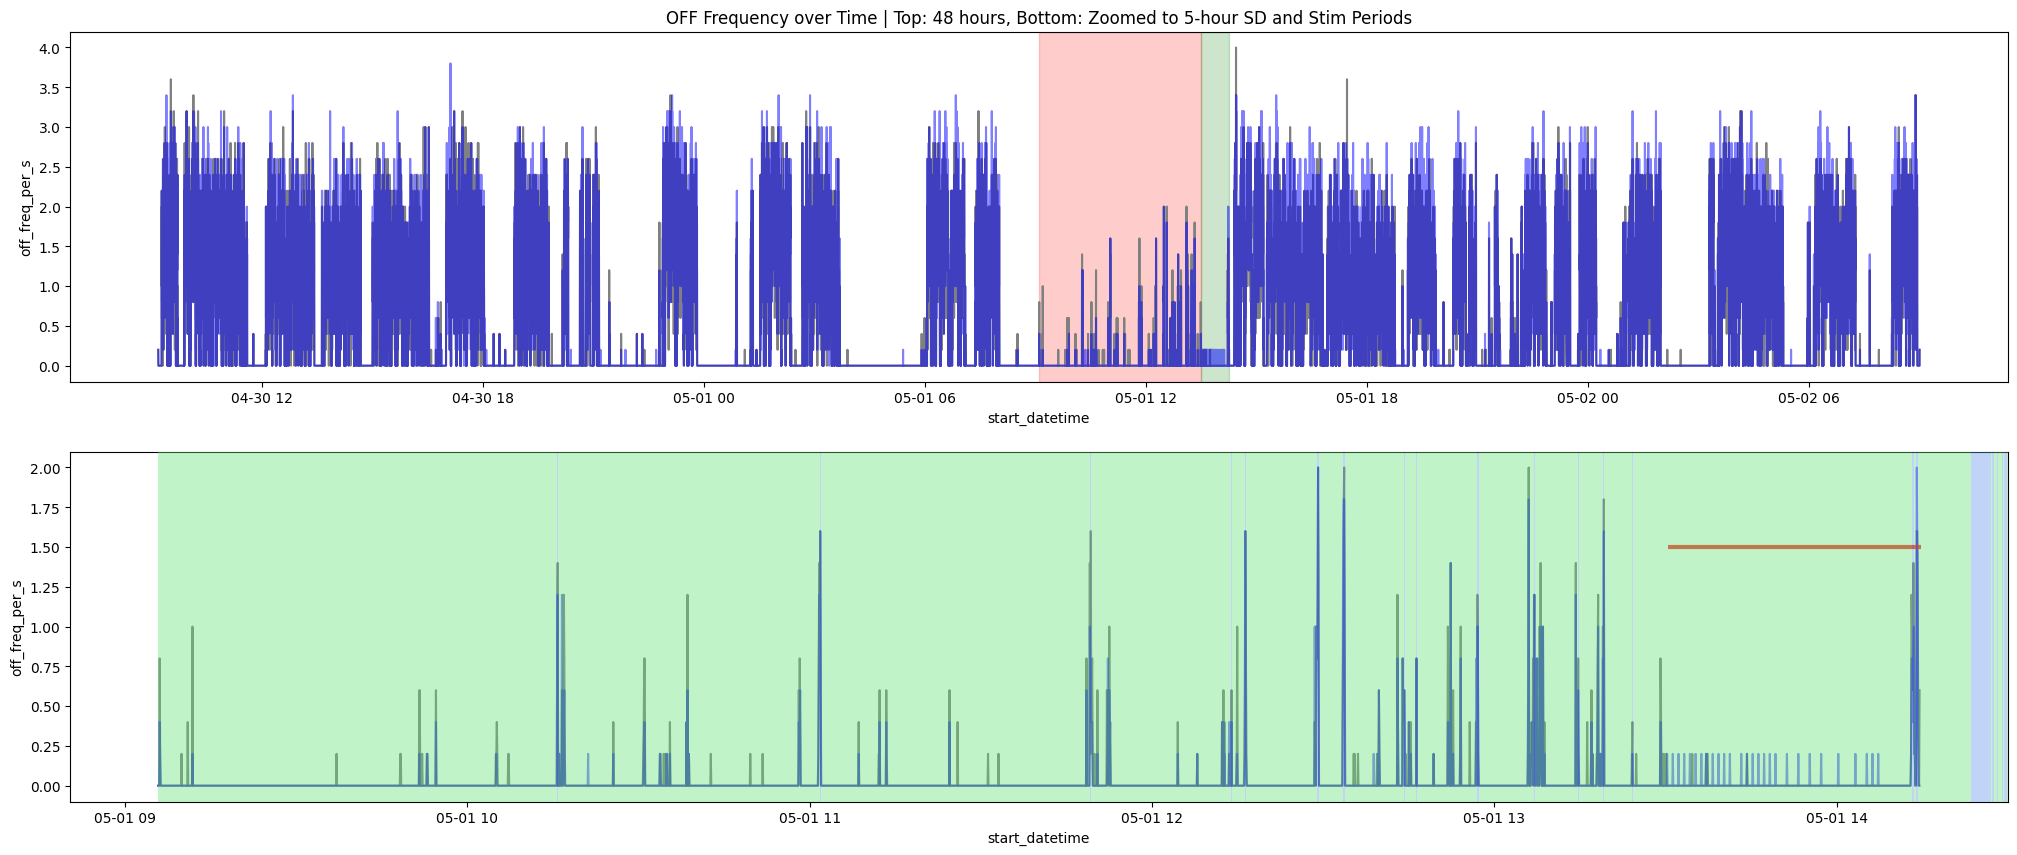

In [109]:
f, ax = plt.subplots(2, 1, figsize=(25, 10))
sns.lineplot(x='start_datetime', y='off_freq_per_s', color='gray', data=wp_freq.prb('NNXr'), alpha=1, ax=ax[0])
sns.lineplot(x='start_datetime', y='off_freq_per_s', color='blue', data=wp_freq.prb('NNXo'), alpha=0.5, ax=ax[0])
ax[0].axvspan(exp_start, stim_start, color='red', alpha=0.2)
ax[0].axvspan(stim_start, stim_end, color='green', alpha=0.2)
sns.lineplot(x='start_datetime', y='off_freq_per_s', color='gray', data=wp_freq.prb('NNXr').oots(exp_start, stim_end), alpha=1, ax=ax[1])
sns.lineplot(x='start_datetime', y='off_freq_per_s', color='blue', data=wp_freq.prb('NNXo').oots(exp_start, stim_end), alpha=0.5, ax=ax[1])

#for i in range(len(pon)):
#    ax[1].axvspan(pon[i], poff[i], color='green', alpha=0.2)
#ax[1].axvspan(exp_start, stim_start, color='red', alpha=0.2)
#ax[1].axvspan(stim_start, stim_end, color='green', alpha=0.2)
ax[1] = kde.plot.main.shade_hypno_for_me(hypno, ax[1], alpha=0.4)
ax[1].hlines(1.5, stim_start, stim_end, color='red', alpha=0.8, linewidth=3)
ax[0].set_title('OFF Frequency over Time | Top: 48 hours, Bottom: Zoomed to 5-hour SD and Stim Periods')

In [110]:
early_sd_period = (exp_start, exp_start + pd.Timedelta(minutes=60))
late_sd_period = (stim_start-pd.Timedelta(minutes=60), stim_start)
stim_periods = [(laser_on, laser_off) for laser_on, laser_off in zip(pon, poff)]
inter_stim_periods = [(poff[i], pon[i+1]) for i in range(len(pon)-1)]

early_sd_dur = sd_dict['early_sd']['duration'].sum().total_seconds()
late_sd_dur = sd_dict['late_sd']['duration'].sum().total_seconds()
stim_dur = sd_dict['stim']['duration'].sum().total_seconds()
inter_stim_dur = sd_dict['inter-stim']['duration'].sum().total_seconds()
durations = {
    'early_sd': early_sd_dur,
    'late_sd': late_sd_dur,
    'stim': stim_dur,
    'inter-stim': inter_stim_dur
}



# create an epoch column in wp_offs that labels each row as 'sd', 'stim', or 'inter-stim'
# based on which period each OFF period's start_datetime falls into
ref = pl.col('start_datetime')

def _in_any(periods):
    expr = pl.lit(False)
    for start, end in periods:
        expr = expr | ref.is_between(start, end)
    return expr

#wp_offs = wp_offs.with_columns(
#    pl.when(ref.is_between(*early_sd_period)).then(pl.lit('early_sd'))
#      .when(ref.is_between(*late_sd_period)).then(pl.lit('late_sd'))
#      .when(_in_any(stim_periods)).then(pl.lit('stim'))
#      .when(_in_any(inter_stim_periods)).then(pl.lit('inter-stim'))
#      .otherwise(None)
#      .alias('epoch')
#)

wp_offs = wp_offs.with_columns(
    pl.col('epoch').replace_strict(durations, default=None).alias('epoch_dur_s')
)
wp_offs = wp_offs.with_columns(
    pl.when(pl.col('epoch') == 'None')
      .then(pl.lit(None).cast(pl.Utf8))
      .otherwise(pl.col('epoch'))
      .alias('epoch')
)

In [111]:
counts = wp_offs.filter(pl.col('epoch').is_not_null()).group_by(['epoch', 'probe']).agg(
    pl.count().alias('num_off_periods'),
    pl.mean('duration').alias('mean_duration'))
counts = counts.with_columns(
    pl.col('epoch').replace_strict(durations, default=None).alias('epoch_dur_s')
)
counts = counts.with_columns(
    (pl.col('num_off_periods') / pl.col('epoch_dur_s')).alias('off_periods_per_s')
)
counts = dag.relativize_df(counts, ref_to_col='epoch', ref_to_val='early_sd', avg_method='mean', col_to_relativize='off_periods_per_s', on=['probe'])
counts = dag.relativize_df(counts, ref_to_col='epoch', ref_to_val='early_sd', avg_method='mean', col_to_relativize='mean_duration', on=['probe'])

results look basically similar to the previous method:

Text(0.5, 1.0, 'Mean OFF Period Frequency by Epoch and Probe, Relative to early SD')

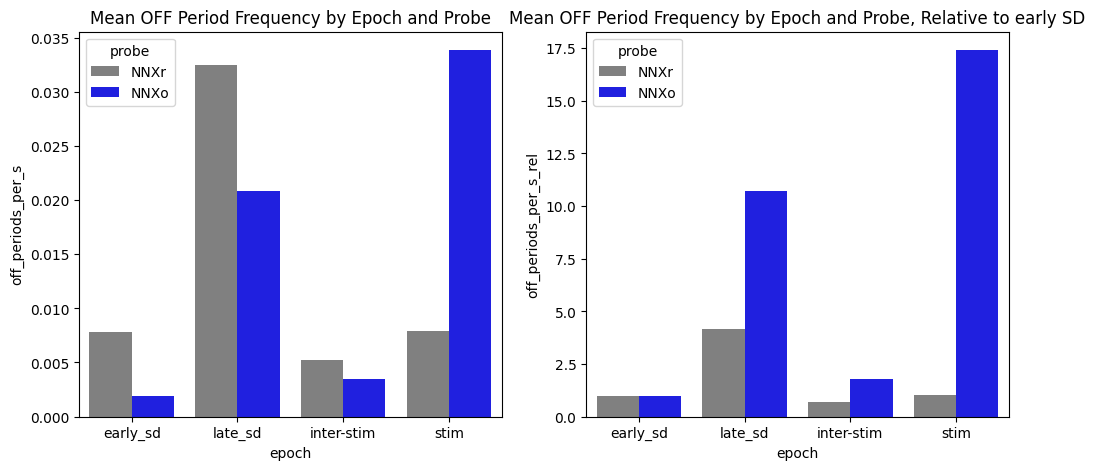

In [112]:
f, ax = plt.subplots(1, 2, figsize=(12, 5))

ax[0] = sns.barplot(data=counts.to_pandas(), x='epoch', y='off_periods_per_s', hue='probe', hue_order=['NNXr', 'NNXo'], order=['early_sd', 'late_sd', 'inter-stim', 'stim'], palette=['gray', 'blue'], ax=ax[0])
ax[0].set_title('Mean OFF Period Frequency by Epoch and Probe')

ax[1] = sns.barplot(data=counts.to_pandas(), x='epoch', y='off_periods_per_s_rel', hue='probe', hue_order=['NNXr', 'NNXo'], order=['early_sd', 'late_sd', 'inter-stim', 'stim'], palette=['gray', 'blue'], ax=ax[1])
ax[1].set_title('Mean OFF Period Frequency by Epoch and Probe, Relative to early SD')

Text(0.5, 1.0, 'Mean OFF Period Duration by Epoch and Probe, Relative to early SD')

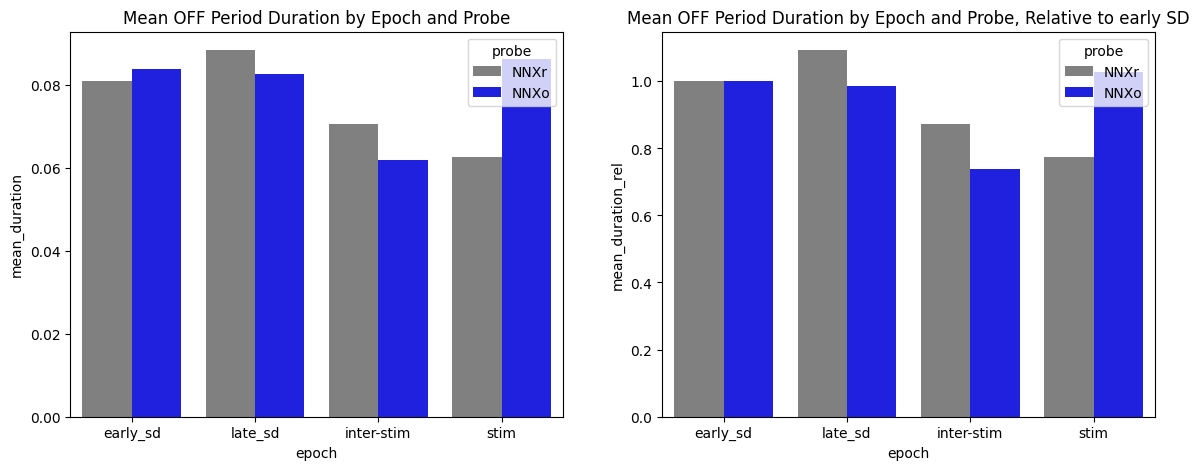

In [113]:
f, ax = plt.subplots(1, 2, figsize=(14, 5))

ax[0] = sns.barplot(data=counts.to_pandas(), x='epoch', y='mean_duration', hue='probe', hue_order=['NNXr', 'NNXo'], order=['early_sd', 'late_sd', 'inter-stim', 'stim'], palette=['gray', 'blue'], ax=ax[0])
ax[0].set_title('Mean OFF Period Duration by Epoch and Probe')
ax[1] = sns.barplot(data=counts.to_pandas(), x='epoch', y='mean_duration_rel', hue='probe', hue_order=['NNXr', 'NNXo'], order=['early_sd', 'late_sd', 'inter-stim', 'stim'], palette=['gray', 'blue'], ax=ax[1])
ax[1].set_title('Mean OFF Period Duration by Epoch and Probe, Relative to early SD')

# Are OFFs on the optrode being induced by the pulse itself?

In [114]:
probe = 'NNXo'
_probe_lfps = []
for pulse in pon:
    pulse_lfp = lfp.prb(probe).sel(datetime=slice(pulse-pd.Timedelta(seconds=1), pulse + pd.Timedelta(seconds=3))) 
    _probe_lfps.append(pulse_lfp.data)
probe_lfps = []
for p in _probe_lfps:
    if p.shape[0] != 1601:
        p = np.pad(p, ((0, 1), (0, 0)), mode='constant', constant_values=0)
    probe_lfps.append(p)
probe_lfp_array = np.stack(probe_lfps)
lfp_means = probe_lfp_array.mean(axis=0)
lfp_sems = probe_lfp_array.std(axis=0) / np.sqrt(probe_lfp_array.shape[0])

In [115]:
bins = {}
mua = mua.sort('datetime')
for probe in ['NNXo', 'NNXr']:
    probe_mua = mua.filter(pl.col('probe') == probe)
    dtfull = probe_mua['datetime'].to_numpy()
    st_by_chan = []
    channels = probe_mua['channel'].unique()
    channels = channels.sort()
    for channel in channels:
        print(probe, channel)
        st_by_chan.append(probe_mua.filter(pl.col('channel') == channel)['datetime'].to_numpy())
    bins[probe] = acr.onoffmua.bin_spikes(st_by_chan, dtfull[0], dtfull[-1])

NNXo 1
NNXo 2
NNXo 3
NNXo 4
NNXo 5
NNXo 6
NNXo 7
NNXo 8
NNXo 9
NNXo 10
NNXo 11
NNXo 12
NNXo 13
NNXo 14
NNXo 15
NNXo 16
NNXr 1
NNXr 2
NNXr 3
NNXr 4
NNXr 5
NNXr 6
NNXr 7
NNXr 8
NNXr 9
NNXr 10
NNXr 11
NNXr 12
NNXr 13
NNXr 14
NNXr 15
NNXr 16


In [116]:
probe = 'NNXo'
probe_pulse_counts = []
for pulse in pon:
    pulse_counts = bins[probe].sel(datetime=slice(pulse-pd.Timedelta(seconds=1), pulse + pd.Timedelta(seconds=3))) 
    probe_pulse_counts.append(pulse_counts.sum(dim='channel').data)

In [117]:
probe_pulse_array = np.stack(probe_pulse_counts)
probe_pulse_mean = probe_pulse_array.mean(axis=0)
probe_pulse_sem = probe_pulse_array.std(axis=0) / np.sqrt(probe_pulse_array.shape[0])

Averaging together all pulses, two things are clear (shown in the below two plots respectively):
1. There is a sharp transient decrease in MUA activity immediately following the onset of the laser pulse (i.e. an OFF period)
2. There is clear positive deflection in the LFP immediately following the onset of the laser pulse (i.e. a slow wave)

Text(0, 0.5, 'Mean MUA Spike Count, 1ms bins')

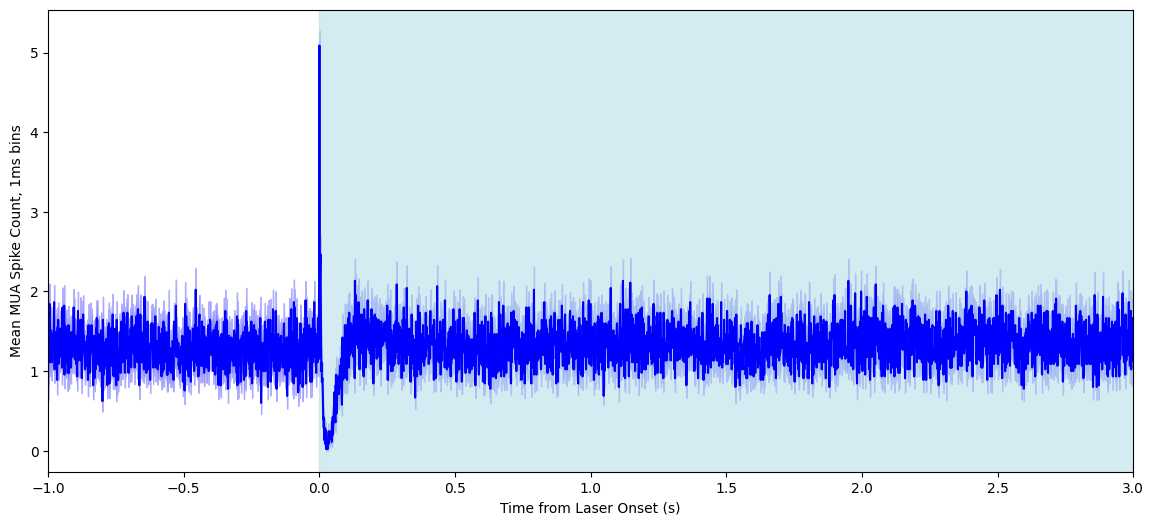

In [118]:
plt.rcdefaults()
f, ax = plt.subplots(figsize=(14, 6))
time_bins = np.arange(-1, 3, 0.001)
ax.plot(time_bins, probe_pulse_mean, color='blue')
ax.fill_between(time_bins, probe_pulse_mean - probe_pulse_sem, probe_pulse_mean + probe_pulse_sem, color='blue', alpha=0.3)
ax.axvspan(0, 3, color='lightblue', alpha=0.5)
ax.set_xlim(-1, 3)
ax.set_xlabel('Time from Laser Onset (s)')
ax.set_ylabel('Mean MUA Spike Count, 1ms bins')

LFP, same exact timescale as MUA above:

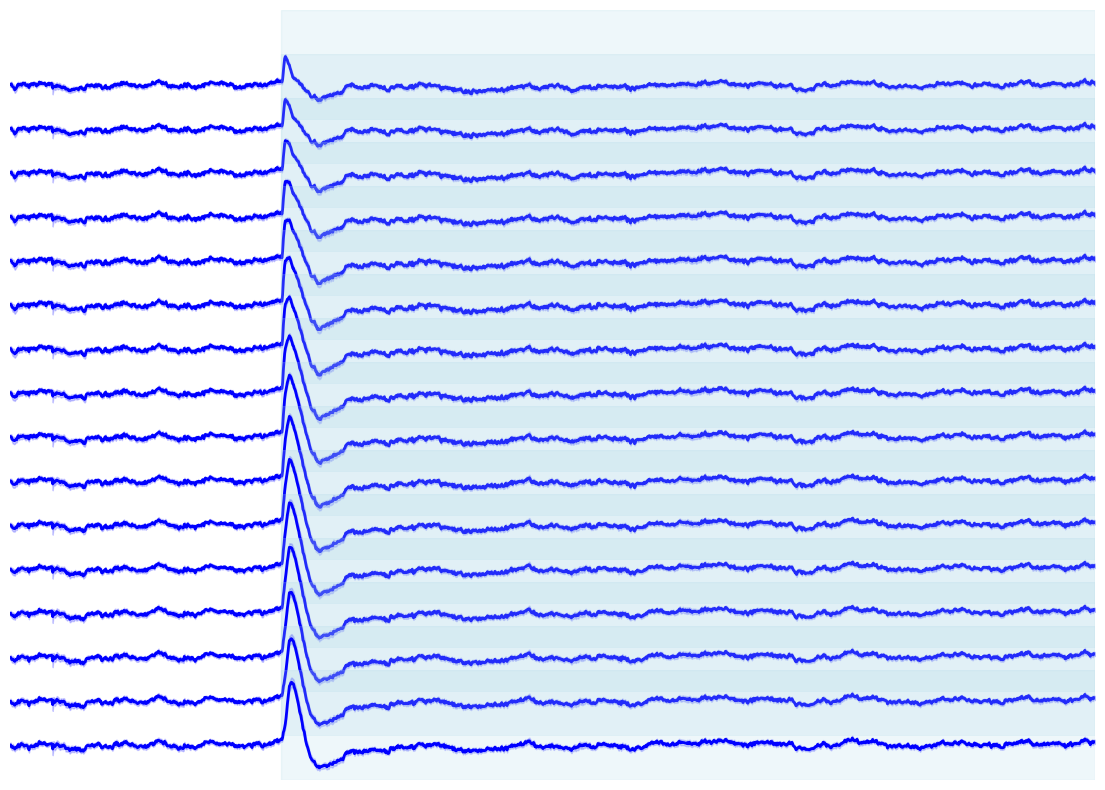

In [119]:
n_time_points = lfp_means.shape[0]
time_bins = np.linspace(-1, 3, n_time_points)

f, ax = kde.plot.main.atomic_lfp(lfp_means.T, times=time_bins, sems=lfp_sems.T, figsize=(14, 10))
for a in ax:
    a.axvspan(0, 3, color='lightblue', alpha=0.2)

# Overall Firing Rate, stim vs interstimulus interval

In [120]:
early_sd_period = (exp_start, exp_start + pd.Timedelta(minutes=60))
late_sd_period = (stim_start-pd.Timedelta(minutes=60), stim_start)
stim_periods = [(laser_on, laser_off) for laser_on, laser_off in zip(pon, poff)]
inter_stim_periods = [(poff[i], pon[i+1]) for i in range(len(pon)-1)]

early_sd_dur = 3600
late_sd_dur = 3600
stim_dur = 20*len(stim_periods)
inter_stim_dur = 40*len(inter_stim_periods)
durations = {
    'early_sd': early_sd_dur,
    'late_sd': late_sd_dur,
    'stim': stim_dur,
    'inter-stim': inter_stim_dur
}

# create an epoch column in wp_offs that labels each row as 'sd', 'stim', or 'inter-stim'
# based on which period each OFF period's start_datetime falls into
ref = pl.col('datetime')

def _in_any(periods):
    expr = pl.lit(False)
    for start, end in periods:
        expr = expr | ref.is_between(start, end)
    return expr

mua = mua.with_columns(
    pl.when(ref.is_between(*early_sd_period)).then(pl.lit('early_sd'))
      .when(ref.is_between(*late_sd_period)).then(pl.lit('late_sd'))
      .when(_in_any(stim_periods)).then(pl.lit('stim'))
      .when(_in_any(inter_stim_periods)).then(pl.lit('inter-stim'))
      .otherwise(None)
      .alias('epoch')
)

mua = mua.with_columns(
    pl.col('epoch').replace_strict(durations, default=None).alias('epoch_dur_s')
)

In [121]:
muaeps = mua.filter(pl.col('epoch').is_not_null())

In [122]:
muaeps_counts = muaeps.group_by(['epoch', 'probe']).agg(
    pl.count().alias('num_spikes'),
    pl.col('epoch_dur_s').first().alias('epoch_dur_s'))
muaeps_counts = muaeps_counts.with_columns(
    (pl.col('num_spikes') / pl.col('epoch_dur_s')).alias('firing_rate')
)
muaeps_counts = dag.relativize_df(muaeps_counts, ref_to_col='epoch', ref_to_val='early_sd', avg_method='mean', col_to_relativize='firing_rate', on=['probe'])

OVERALL firing rate during SOM+ inhibition does appear to be slighly increased on the optrode relative to contralateral control, and relative to the inter-stimulus period on the optrode:

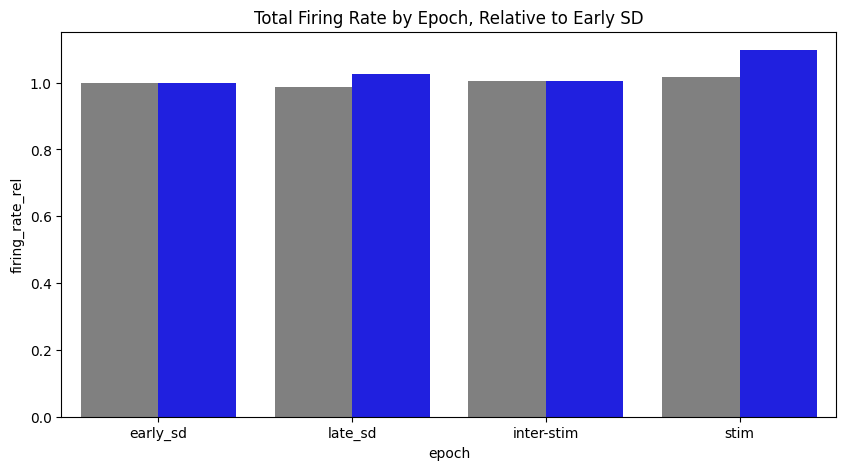

In [124]:
plt.rcdefaults()
f, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=muaeps_counts.to_pandas(), x='epoch', y='firing_rate_rel', hue='probe', hue_order=['NNXr', 'NNXo'], order=['early_sd', 'late_sd', 'inter-stim', 'stim'], palette=['gray', 'blue'], ax=ax)
ax.set_title('Total Firing Rate by Epoch, Relative to Early SD')
#remove the legend
ax.legend_.remove()

Breakdown by channel:

In [125]:
muaeps_counts = muaeps.group_by(['epoch', 'probe', 'channel']).agg(
    pl.count().alias('num_spikes'),
    pl.col('epoch_dur_s').first().alias('epoch_dur_s'))
muaeps_counts = muaeps_counts.with_columns(
    (pl.col('num_spikes') / pl.col('epoch_dur_s')).alias('firing_rate')
)
muaeps_counts = dag.relativize_df(muaeps_counts, ref_to_col='epoch', ref_to_val='early_sd', avg_method='mean', col_to_relativize='firing_rate', on=['probe', 'channel'])

Text(0.5, 1.0, 'Stim FR | Relative to Early SD')

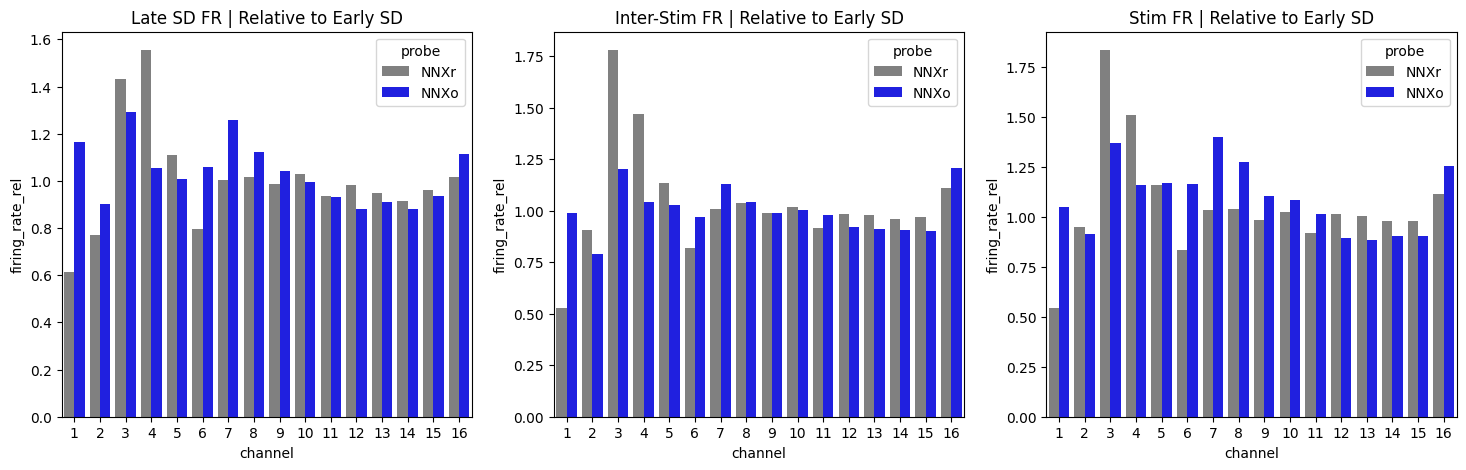

In [126]:
plt.rcdefaults()
f, ax = plt.subplots(1, 3, figsize=(18, 5))
ax[0] = sns.barplot(data=muaeps_counts.filter(pl.col('epoch')=='late_sd'), x='channel', y='firing_rate_rel', hue='probe', hue_order=['NNXr', 'NNXo'], palette=['gray', 'blue'], ax=ax[0])
ax[0].set_title('Late SD FR | Relative to Early SD')
ax[1] = sns.barplot(data=muaeps_counts.filter(pl.col('epoch')=='inter-stim'), x='channel', y='firing_rate_rel', hue='probe', hue_order=['NNXr', 'NNXo'], palette=['gray', 'blue'], ax=ax[1])
ax[1].set_title('Inter-Stim FR | Relative to Early SD')
ax[2] = sns.barplot(data=muaeps_counts.filter(pl.col('epoch')=='stim'), x='channel', y='firing_rate_rel', hue='probe', hue_order=['NNXr', 'NNXo'], palette=['gray', 'blue'], ax=ax[2])
ax[2].set_title('Stim FR | Relative to Early SD')

# What if we remove the initial OFF periods associated with each laser-ON transient?

To remove the effect of the laser pulse itself, here we exclude from the 'stim' condition the first 500ms following the onset of each laser pulse. 

In [138]:
true_sd_start = hypno['start_time'][0]
sd_dict = {}
sd_dict['early_sd'] = hypno.keep_states(['Wake']).keep_first('3600s')
sd_dict['late_sd'] = hypno.trim_select(true_sd_start, stim_start).keep_states(['Wake']).keep_last('3600s')
#sd_dict['stim'] = pl.DataFrame({'start_datetime': [stim_start], 'end_datetime': [stim_end], 'state': ['Wake'], 'duration': [pd.Timedelta(stim_end - stim_start).total_seconds()]})

In [139]:
stim_hypnos = []
for s, e in zip(pon, poff):
    new_start = s + pd.Timedelta('250ms')
    stim_hypno = hypno.trim_select(new_start, e).keep_states(['Wake'])
    stim_hypnos.append(stim_hypno._df)
full_stim_hypno = DatetimeHypnogram(pd.concat(stim_hypnos))
sd_dict['stim'] = full_stim_hypno

In [140]:
interval_hypnos = []
for i in range(len(pon)-1):
    s = poff[i]
    e = pon[i+1]
    interval_hypno = hypno.trim_select(s, e).keep_states(['Wake'])
    interval_hypnos.append(interval_hypno._df)
full_interval_hypno = DatetimeHypnogram(pd.concat(interval_hypnos))
sd_dict['inter-stim'] = full_interval_hypno

In [141]:
wp_offs = acr.onoffmua.compute_hybrid_off_df(subject, exp)

wp_offs = acr.hypnogram_utils.label_df_with_hypno_conditions(wp_offs, sd_dict, col='end_datetime', label_col='epoch')
wp_offs = acr.hypnogram_utils.label_df_with_states(wp_offs, hypno, col='end_datetime')
wp_freq = acr.oo_utils.calc_off_freq(wp_offs, window='5s')

In [142]:
early_sd_period = (exp_start, exp_start + pd.Timedelta(minutes=60))
late_sd_period = (stim_start-pd.Timedelta(minutes=60), stim_start)
stim_periods = [(laser_on, laser_off) for laser_on, laser_off in zip(pon, poff)]
inter_stim_periods = [(poff[i], pon[i+1]) for i in range(len(pon)-1)]

early_sd_dur = sd_dict['early_sd']['duration'].sum().total_seconds()
late_sd_dur = sd_dict['late_sd']['duration'].sum().total_seconds()
stim_dur = sd_dict['stim']['duration'].sum().total_seconds()
inter_stim_dur = sd_dict['inter-stim']['duration'].sum().total_seconds()
durations = {
    'early_sd': early_sd_dur,
    'late_sd': late_sd_dur,
    'stim': stim_dur,
    'inter-stim': inter_stim_dur
}



# create an epoch column in wp_offs that labels each row as 'sd', 'stim', or 'inter-stim'
# based on which period each OFF period's start_datetime falls into
ref = pl.col('start_datetime')

def _in_any(periods):
    expr = pl.lit(False)
    for start, end in periods:
        expr = expr | ref.is_between(start, end)
    return expr

#wp_offs = wp_offs.with_columns(
#    pl.when(ref.is_between(*early_sd_period)).then(pl.lit('early_sd'))
#      .when(ref.is_between(*late_sd_period)).then(pl.lit('late_sd'))
#      .when(_in_any(stim_periods)).then(pl.lit('stim'))
#      .when(_in_any(inter_stim_periods)).then(pl.lit('inter-stim'))
#      .otherwise(None)
#      .alias('epoch')
#)

wp_offs = wp_offs.with_columns(
    pl.col('epoch').replace_strict(durations, default=None).alias('epoch_dur_s')
)
wp_offs = wp_offs.with_columns(
    pl.when(pl.col('epoch') == 'None')
      .then(pl.lit(None).cast(pl.Utf8))
      .otherwise(pl.col('epoch'))
      .alias('epoch')
)

In [143]:
stim_dur

875.080865

In [144]:
counts = wp_offs.filter(pl.col('epoch').is_not_null()).group_by(['epoch', 'probe']).agg(
    pl.count().alias('num_off_periods'),
    pl.mean('duration').alias('mean_duration'))
counts = counts.with_columns(
    pl.col('epoch').replace_strict(durations, default=None).alias('epoch_dur_s')
)
counts = counts.with_columns(
    (pl.col('num_off_periods') / pl.col('epoch_dur_s')).alias('off_periods_per_s')
)
counts = dag.relativize_df(counts, ref_to_col='epoch', ref_to_val='early_sd', avg_method='mean', col_to_relativize='off_periods_per_s', on=['probe'])
counts = dag.relativize_df(counts, ref_to_col='epoch', ref_to_val='early_sd', avg_method='mean', col_to_relativize='mean_duration', on=['probe'])

When expressed relative to the early SD period, there is still an increase in OFF period frequency on the Optrode compared to contralateral control (below, right), as in all analyses above.

However, perhaps the more sensible comparison is to compare the stimulus period to the inter-stimulus interval, since these are directly adjacent and thus more likely to be comparable in terms of overall sleep pressure.

Text(0.5, 1.0, 'Mean OFF Period Frequency by Epoch and Probe, Relative to early SD')

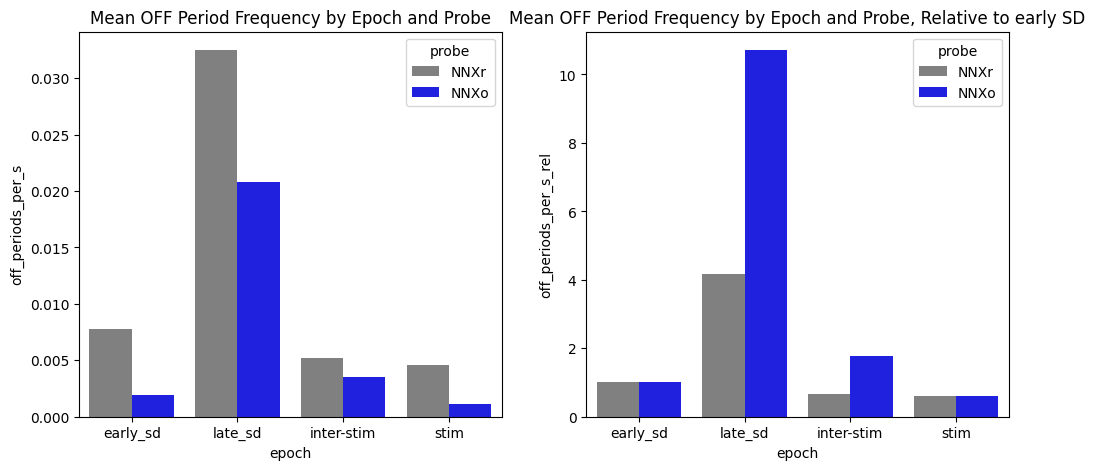

In [145]:
f, ax = plt.subplots(1, 2, figsize=(12, 5))

ax[0] = sns.barplot(data=counts.to_pandas(), x='epoch', y='off_periods_per_s', hue='probe', hue_order=['NNXr', 'NNXo'], order=['early_sd', 'late_sd', 'inter-stim', 'stim'], palette=['gray', 'blue'], ax=ax[0])
ax[0].set_title('Mean OFF Period Frequency by Epoch and Probe')

ax[1] = sns.barplot(data=counts.to_pandas(), x='epoch', y='off_periods_per_s_rel', hue='probe', hue_order=['NNXr', 'NNXo'], order=['early_sd', 'late_sd', 'inter-stim', 'stim'], palette=['gray', 'blue'], ax=ax[1])
ax[1].set_title('Mean OFF Period Frequency by Epoch and Probe, Relative to early SD')

Relativizing the data to the inter-stimulus (laser-OFF) period:

In [146]:
counts = wp_offs.filter(pl.col('epoch').is_not_null()).group_by(['epoch', 'probe']).agg(
    pl.count().alias('num_off_periods'),
    pl.mean('duration').alias('mean_duration'))
counts = counts.with_columns(
    pl.col('epoch').replace_strict(durations, default=None).alias('epoch_dur_s')
)
counts = counts.with_columns(
    (pl.col('num_off_periods') / pl.col('epoch_dur_s')).alias('off_periods_per_s')
)
counts = dag.relativize_df(counts, ref_to_col='epoch', ref_to_val='inter-stim', avg_method='mean', col_to_relativize='off_periods_per_s', on=['probe'])
counts = dag.relativize_df(counts, ref_to_col='epoch', ref_to_val='inter-stim', avg_method='mean', col_to_relativize='mean_duration', on=['probe'])

Text(0.5, 1.0, 'Mean OFF Period Frequency by Epoch and Probe, Relative to Inter-stim')

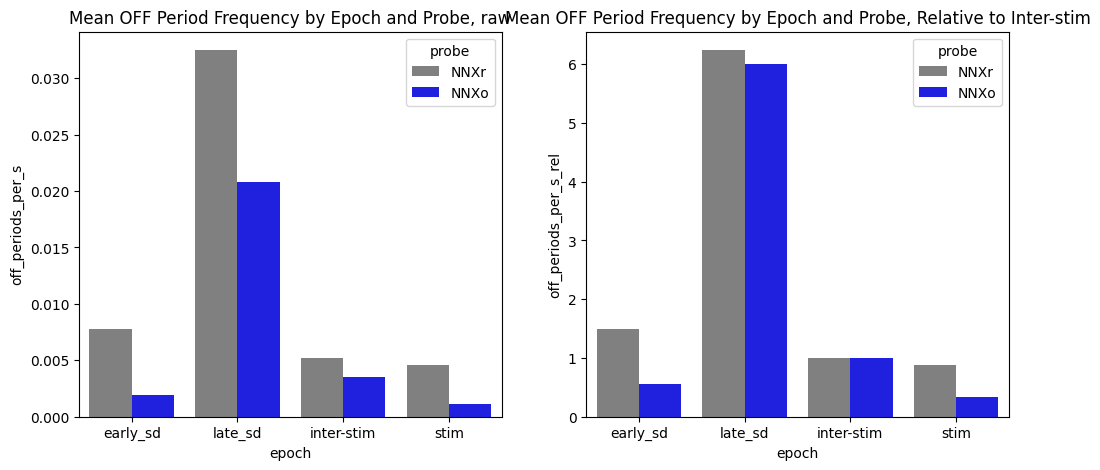

In [147]:
f, ax = plt.subplots(1, 2, figsize=(12, 5))

ax[0] = sns.barplot(data=counts.to_pandas(), x='epoch', y='off_periods_per_s', hue='probe', hue_order=['NNXr', 'NNXo'], order=['early_sd', 'late_sd', 'inter-stim', 'stim'], palette=['gray', 'blue'], ax=ax[0])
ax[0].set_title('Mean OFF Period Frequency by Epoch and Probe, raw')

ax[1] = sns.barplot(data=counts.to_pandas(), x='epoch', y='off_periods_per_s_rel', hue='probe', hue_order=['NNXr', 'NNXo'], order=['early_sd', 'late_sd', 'inter-stim', 'stim'], palette=['gray', 'blue'], ax=ax[1])
ax[1].set_title('Mean OFF Period Frequency by Epoch and Probe, Relative to Inter-stim')

Here we now see what looks like a decrease in off period frequency on the optrode relative to the contralateral control probe during the stimulus period, AND a decrease in off pperiod frequency on the optrode during the stimulus period relative to its own inter-stimulus interval period (perhaps the more relevant comparison).

This also begs the question of whether, at least for this type of experiment, we really need both both implanted.

Counter-intuitively, during SOM+ inhibition, there also appears to be a slight increase in OFF period duration on the optrode relative to the contralateral control probe, though not relative to the optrode's own inter-stimulus interval:

Text(0.5, 1.0, 'Mean OFF Period Duration by Epoch and Probe, Relative to Inter-stim')

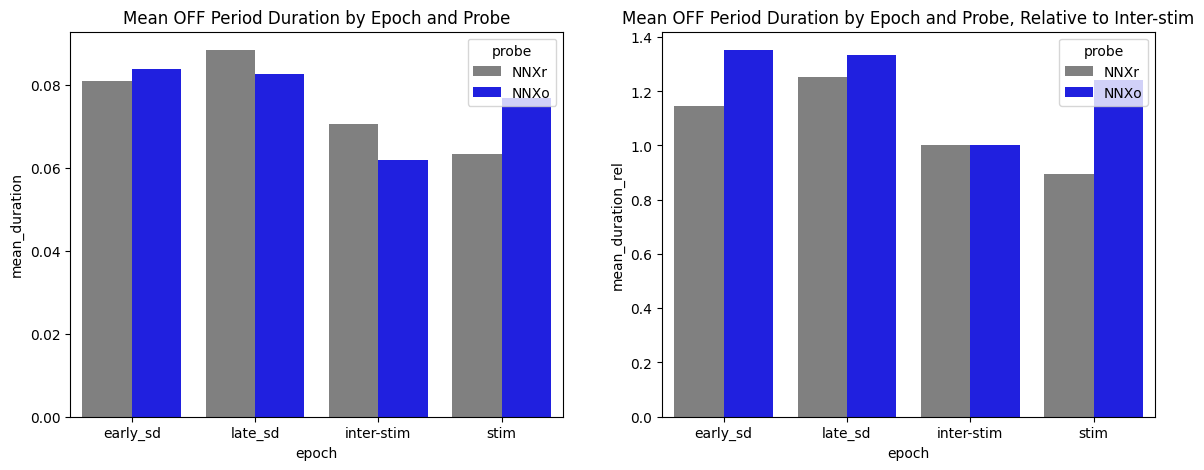

In [148]:
f, ax = plt.subplots(1, 2, figsize=(14, 5))

ax[0] = sns.barplot(data=counts.to_pandas(), x='epoch', y='mean_duration', hue='probe', hue_order=['NNXr', 'NNXo'], order=['early_sd', 'late_sd', 'inter-stim', 'stim'], palette=['gray', 'blue'], ax=ax[0])
ax[0].set_title('Mean OFF Period Duration by Epoch and Probe')
ax[1] = sns.barplot(data=counts.to_pandas(), x='epoch', y='mean_duration_rel', hue='probe', hue_order=['NNXr', 'NNXo'], order=['early_sd', 'late_sd', 'inter-stim', 'stim'], palette=['gray', 'blue'], ax=ax[1])
ax[1].set_title('Mean OFF Period Duration by Epoch and Probe, Relative to Inter-stim')

## Conclusions

When we detect OFF periods just as I did in the Nat Neuro paper, and we remove the initial 500ms after each laser-on pulse (which very confusingly appears to be associated with a positive deflection in the LFP and a strong decrease in total MUA activity), I think we can say the following things based on these analyses with some confidence (note that these statements assume that laser-on actually does achieve SOM+ inhibition, which is not directly verified here):
1. Inhibition of SOM+ is associated with a decrease in OFF period frequency on the optrode compared to the inter-stimulus interval on the optrode when the laser is off. 
2. Inhibition of SOM+ is associated with a decrease in OFF period frequency on the optrode compared to the contralateral control probe during the stimulus period, when both are referenced to their own inter-stimulus intervals. (i.e. it is not the case that the stimulus period is globally associated with a decrease in OFF period frequency - it occurs specifically on the optrode).
3. The confidence in the above two statements is slightly limited by the fact that the optrode OFF period frequency is already lower than contralateral control side during late SD relative to the inter-stimulus period. Nonetheless, I think that the best comparison is between the stimulus and inter-stimulus periods. 